In [31]:
import os
import pandas as pd
import numpy as np
import re
import utils

In [32]:
# Make output folder
output_dir = os.path.join('..','..','..','plots','modelling')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [33]:
preprocessed_model_fit_folder = f'/Volumes/project/3025011.02/pre-processed/modelling/model_fit'
model_fit_pattern = re.compile(r'^model_fit_sub-\d{3}_session-\d{2}\.csv$')

## Which subjects and sessions do we want to include?

In [34]:
unique_subject_ids = [5, 10, 14, 15, 16, 20, 22, 23, 25, 28, 29, 37] #[5, 10, 13, 14, 15, 16, 20, 22, 23, 25, 27, 28, 29, 30, 32, 37]
unique_sessions = [2, 3, 4]

In [35]:
model_fit_combined = []
# Iterate through files in the folder
for file_name in os.listdir(preprocessed_model_fit_folder):
    if model_fit_pattern.match(file_name):
        path = os.path.join(preprocessed_model_fit_folder, file_name)
        model_fit = pd.read_csv(path)
        model_fit_combined.append(model_fit)

model_fit_combined = pd.concat(model_fit_combined, ignore_index=True)
model_fit_combined = model_fit_combined.sort_values(by=['subject', 'session'])
print(model_fit_combined)

    subject  session  trials   model0_ll  model0_q_happy_pull  \
26        5        1     646 -433.348327             1.000000   
4         5        2     656 -453.861715            -0.107609   
1         5        3     655 -451.260352             0.311884   
7         5        4     660 -453.183480             0.238214   
3        10        1     658 -454.762216            -0.048247   
9        10        2     655 -451.443903            -0.367279   
6        10        3     658 -456.060504            -0.285406   
19       10        4     654 -453.131677             0.604347   
45       13        1     629 -432.921191            -1.000000   
46       13        2     378 -260.599975            -0.162482   
28       14        1     648 -447.990521            -0.324752   
18       14        2     658 -455.494915            -0.088595   
15       14        3     656 -451.129295            -0.342313   
10       14        4     655 -453.948784            -0.496545   
0        15        1     

In [36]:
## Only keep the rows with subjects and sessions we want
model_fit_combined = model_fit_combined[
    model_fit_combined['subject'].isin(unique_subject_ids) &
    model_fit_combined['session'].isin(unique_sessions)
]

In [37]:
# Automatically detect models
models = [col.split('_')[0] for col in model_fit_combined.columns if '_ll' in col]
models = sorted(set(models))

In [38]:
# Initialize dictionaries for AIC/BIC
for model in models:
    # Count the number of parameters per model
    param_cols = [col for col in model_fit_combined.columns if col.startswith(model + '_') and col != model + '_ll']
    k = len(param_cols)

    # Get negative log-likelihoods
    ll = model_fit_combined[f'{model}_ll']
    #ll = -neg_ll  # Convert to positive log-likelihood

    # Calculate AIC and BIC
    model_fit_combined[f'{model}_AIC'] = 2 * k - 2 * ll
    model_fit_combined[f'{model}_BIC'] = k * np.log(model_fit_combined['trials']) - 2 * ll

print(model_fit_combined)

    subject  session  trials   model0_ll  model0_q_happy_pull  \
4         5        2     656 -453.861715            -0.107609   
1         5        3     655 -451.260352             0.311884   
7         5        4     660 -453.183480             0.238214   
9        10        2     655 -451.443903            -0.367279   
6        10        3     658 -456.060504            -0.285406   
19       10        4     654 -453.131677             0.604347   
18       14        2     658 -455.494915            -0.088595   
15       14        3     656 -451.129295            -0.342313   
10       14        4     655 -453.948784            -0.496545   
5        15        2     659 -456.691448            -0.144006   
11       15        3     656 -454.248777             0.767021   
8        15        4     658 -451.563420            -0.753340   
24       16        2     642 -444.873519            -0.837682   
23       16        3     636 -439.050426            -0.204905   
14       20        2     

In [39]:
# Fixed effects group comparison for AIC and BIC
# Take columns that contain AIC or BIC
aic_bic_cols = [col for col in model_fit_combined.columns if 'AIC' in col or 'll' in col]

# Build the total row as a dict comprehension
total_row = {
    col: model_fit_combined[col].sum()   if col in aic_bic_cols
         else 0
    for col in model_fit_combined.columns
}

# Overwrite the session/subject entries
total_row['subject'] = 'total'
total_row['session'] = 'total'

# Add the total row to the DataFrame
total_df = pd.DataFrame([total_row])
model_fit_combined = pd.concat([model_fit_combined, total_df], ignore_index=True)
print(model_fit_combined)

   subject session  trials     model0_ll  model0_q_happy_pull  \
0        5       2     656   -453.861715            -0.107609   
1        5       3     655   -451.260352             0.311884   
2        5       4     660   -453.183480             0.238214   
3       10       2     655   -451.443903            -0.367279   
4       10       3     658   -456.060504            -0.285406   
5       10       4     654   -453.131677             0.604347   
6       14       2     658   -455.494915            -0.088595   
7       14       3     656   -451.129295            -0.342313   
8       14       4     655   -453.948784            -0.496545   
9       15       2     659   -456.691448            -0.144006   
10      15       3     656   -454.248777             0.767021   
11      15       4     658   -451.563420            -0.753340   
12      16       2     642   -444.873519            -0.837682   
13      16       3     636   -439.050426            -0.204905   
14      20       2     63

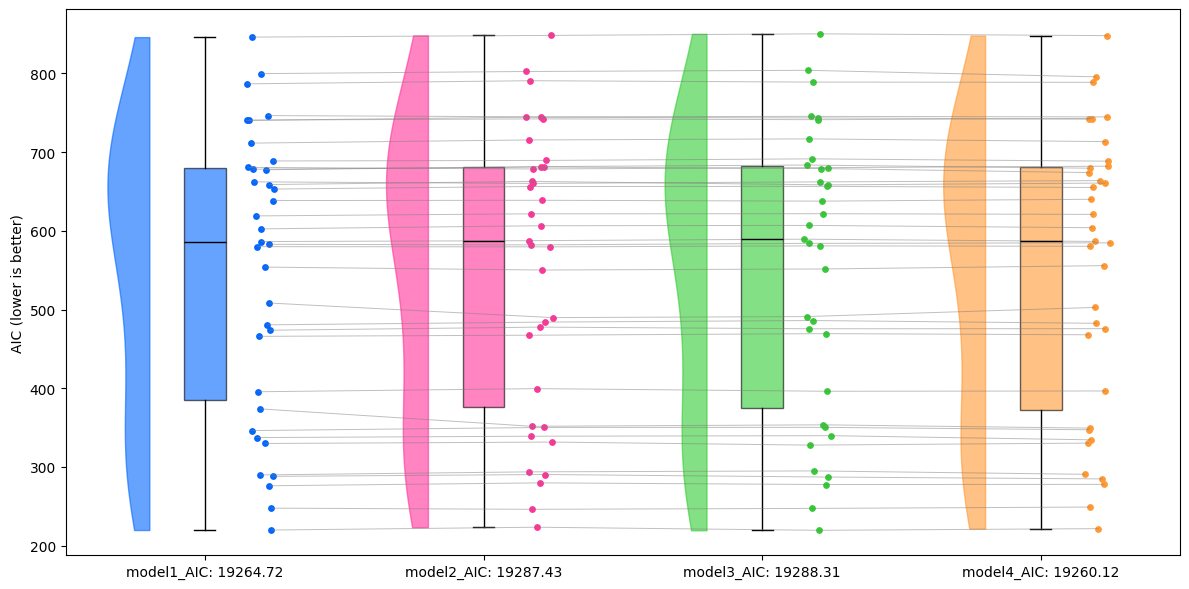

In [40]:
# Remove total column
model_fit_plot = model_fit_combined[model_fit_combined['subject'] != 'total']
model_fit_total = model_fit_combined[model_fit_combined['subject'] == 'total']

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    model_fit_plot,
    columns=['model1_AIC', 'model2_AIC', 'model3_AIC', 'model4_AIC'],
    labels=[f'model1_AIC: {model_fit_total["model1_AIC"].iloc[0]:.2f}', f'model2_AIC: {model_fit_total["model2_AIC"].iloc[0]:.2f}', f'model3_AIC: {model_fit_total["model3_AIC"].iloc[0]:.2f}', f'model4_AIC: {model_fit_total["model4_AIC"].iloc[0]:.2f}'],
    output_dir=output_dir,
    ylabel_name='AIC (lower is better)',
    plot_name='model_comparison_AIC'
)

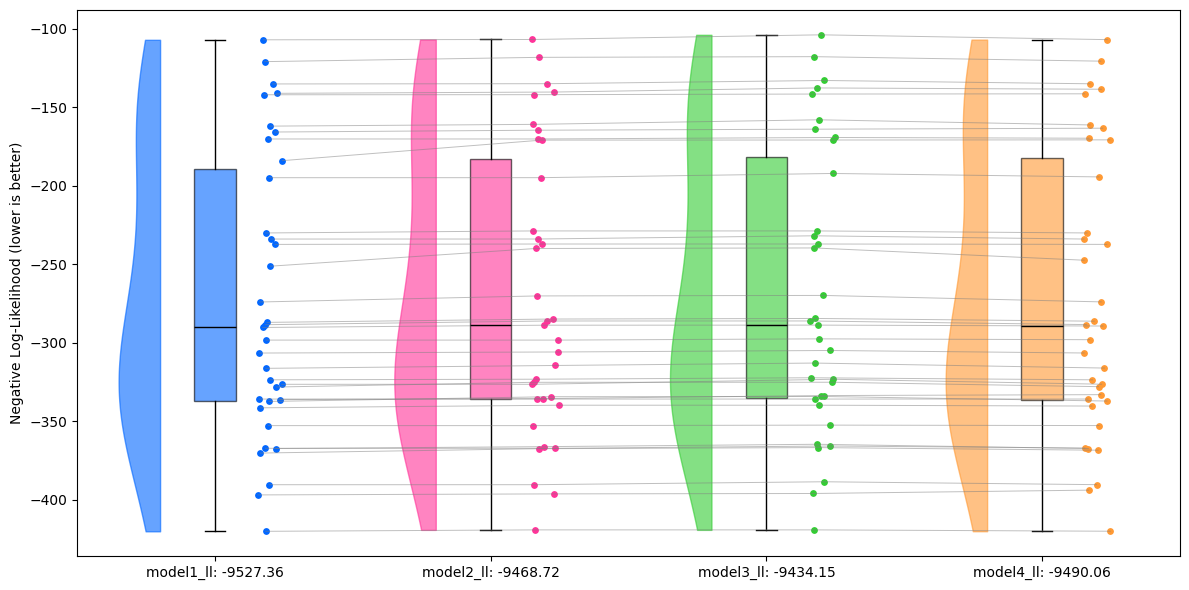

In [41]:
# Remove total column
model_fit_plot = model_fit_combined[model_fit_combined['subject'] != 'total']
model_fit_total = model_fit_combined[model_fit_combined['subject'] == 'total']

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    model_fit_plot,
    columns=['model1_ll', 'model2_ll', 'model3_ll','model4_ll'],
    labels=[f'model1_ll: {model_fit_total["model1_ll"].iloc[0]:.2f}', f'model2_ll: {model_fit_total["model2_ll"].iloc[0]:.2f}', f'model3_ll: {model_fit_total["model3_ll"].iloc[0]:.2f}', f'model4_ll: {model_fit_total["model4_ll"].iloc[0]:.2f}'],
    output_dir=output_dir,
    ylabel_name='Negative Log-Likelihood (lower is better)',
    plot_name='model_comparison_negative_log_likelihood'
)

In [42]:
# Print and save
print(model_fit_combined[['subject'] + [col for col in model_fit_combined.columns if 'AIC' in col or 'BIC' in col]])
model_fit_combined.to_csv(f'{preprocessed_model_fit_folder}/model_fit_combination.csv', index=False, sep=';')

   subject    model0_AIC  model0_BIC    model1_AIC  model1_BIC    model2_AIC  \
0        5    919.723430  946.640395    579.838668  593.297150    579.578748   
1        5    914.520703  941.428515    473.691996  487.145902    477.650243   
2        5    918.366959  945.320398    508.261601  521.738321    489.725423   
3       10    914.887806  941.795617    337.367618  350.821524    339.069584   
4       10    924.121008  951.056238    346.233623  359.701238    350.234078   
5       10    918.263353  945.161998    276.145267  289.594589    279.829209   
6       14    922.989829  949.925059    799.587722  813.055337    802.281817   
7       14    914.258590  941.175555    786.603032  800.061514    790.571332   
8       14    919.897569  946.805380    586.315108  599.769013    587.435517   
9       15    925.382896  952.327237    373.828760  387.300930    351.693675   
10      15    920.497554  947.414519    288.093047  301.551530    290.452467   
11      15    915.126840  942.062069    

In [43]:
# Prepare for Bayesian model selection
## Remove total row
model_fit_comparison = model_fit_combined.drop(model_fit_combined.tail(1).index,inplace=False)
## Extract AIC values into a matrix
aic_columns = [f'model{i}_AIC' for i in range(len(models))]
## Convert AIC to log model evidence
log_evidence_array = model_fit_comparison[aic_columns].values / -2

print(log_evidence_array)

[[-459.86171502 -289.91933377 -289.7893741  -290.41553004 -290.15675878
  -287.05824737]
 [-457.26035164 -236.84599805 -238.82512165 -237.77776272 -237.84217017
  -237.36535271]
 [-459.18347974 -254.13080054 -244.8627116  -245.5140761  -251.32733883
  -253.94128262]
 [-457.44390295 -168.68380891 -169.53479195 -169.88536659 -167.25687181
  -166.73207719]
 [-462.06050406 -173.11681175 -175.11703883 -175.16633631 -173.6364812
  -173.47384844]
 [-459.1316767  -138.07263334 -139.91460447 -138.86419312 -138.96488914
  -124.32860869]
 [-461.49491456 -399.79386104 -401.1409085  -401.89298888 -397.76004958
  -398.44311302]
 [-457.12929491 -393.30151577 -395.28566589 -394.4177793  -394.26138996
  -393.7478225 ]
 [-459.9487845  -293.15755381 -293.71775857 -294.66005435 -293.22811027
  -292.44366423]
 [-462.69144801 -186.91437983 -175.84683767 -176.77392971 -174.68039781
  -178.06686408]
 [-460.24877702 -144.04652372 -145.22623339 -143.61405134 -142.43902506
  -144.85476297]
 [-457.56341984 -109.9

In [44]:
# Bayesian model selection
bms_result = utils.bayesian_model_selection.bms(log_evidence_array)
bms_result.to_csv(f'{preprocessed_model_fit_folder}/model_fit_bayesian_comparison.csv', index=False, sep=';')
print(bms_result)

   alpha_post   xp           pxp          nfe           bor
0    1.000000  0.0  5.871952e-08 -9575.077658  3.523171e-07
1    1.693166  0.0  5.871952e-08 -9575.077658  3.523171e-07
2    3.177461  0.0  5.871952e-08 -9575.077658  3.523171e-07
3    1.725149  0.0  5.871952e-08 -9575.077658  3.523171e-07
4    2.974260  0.0  5.871952e-08 -9575.077658  3.523171e-07
5   30.429964  1.0  9.999997e-01 -9575.077658  3.523171e-07
